In [1]:
import sys
import os
# Add the project root to sys.path to allow imports from src
project_root = os.path.abspath(os.path.join(os.getcwd(), '../../'))
if project_root not in sys.path:
    sys.path.append(project_root)


# Setup

In [2]:
import os

import dill
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpy.random as rd
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from numpy.typing import ArrayLike
from scipy import stats
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm.auto import tqdm

from model.vectorized_model import VectorizedModel
from utils.network_utils import calculate_degree_gini
from networks.variation_methods import generate_densify_variant, generate_equalize_variant

/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Replicating Zollman (2007)

Zollman (2007): 
- n_experiments = 1,000
- uncertainty = 0.001
- steps = 10,000
- n_simulations = 10_000

In [3]:
import pandas as pd
import networkx as nx
from model.vectorized_model import VectorizedModel
from tqdm.auto import tqdm
import seaborn as sns

## Simple networks

In [4]:
def simple_network(n_agents: int,shape: str) -> nx.Graph:
    net = nx.Graph()
    agents = range(n_agents)
    net.add_nodes_from(agents)
    
    if shape == "cycle":
        for agent in range(n_agents):
            net.add_edge(agent, (agent + 1) % n_agents)
            net.add_edge(agent, (agent - 1) % n_agents)
    elif shape == "wheel":
        net.add_edges_from([(0, agent) for agent in agents if agent != 0])
        net.add_edge(1, n_agents - 1)
        for agent in range(1, n_agents):
            net.add_edge(agent, (agent + 1) % n_agents)
            net.add_edge(agent, (agent - 1) % n_agents)

    elif shape == "complete":
        net.add_edges_from(
            [(agent1, agent2) for agent1 in agents for agent2 in agents if agent1 != agent2]
        )
    return net

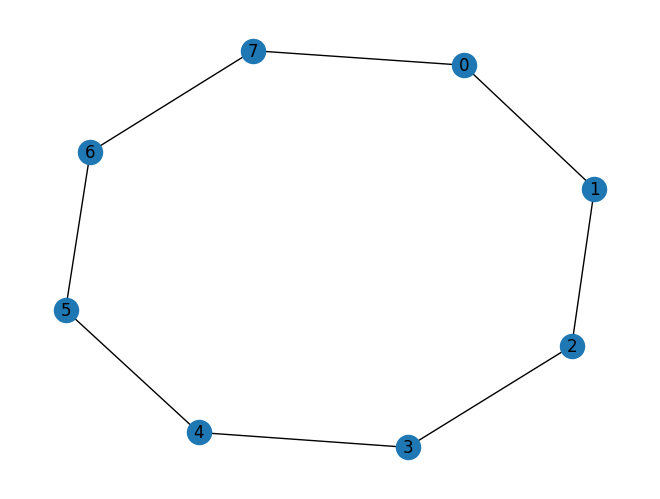

In [5]:
net = simple_network(8, "cycle")
nx.spring_layout(net)
nx.draw(net, with_labels=True)

## Simulations

In [6]:
n_simulations = 10_000
params_simple = [
    {
        "n_agents": n_agents,
        "shape": shape, 
        "agent_type": "bayes",
        "n_steps": 10_000, 
    } 
    for _ in range(n_simulations)
    for n_agents in range(5, 11)
    for shape in ["cycle", "wheel", "complete"]
]
def simulation_simple(
    n_agents: int,
    shape: str,
    agent_type: str,
    n_steps: int,
) -> dict:
    net = simple_network(n_agents, shape)
    model = VectorizedModel(
        network=net,
        n_experiments=1_000,
        uncertainty=0.001,
        agent_type=agent_type,
    )
    model.run_simulation(number_of_steps=n_steps)
    result = {
        "n_agents": n_agents,
        "shape": shape,
        "conclusion": model.conclusion,
        "steps": model.n_steps,
    }
    return result

data = list(tqdm(Parallel(return_as="generator", n_jobs=-2)(
    delayed(simulation_simple)(**params) 
    for params in params_simple
), total=len(params_simple), desc="Progress"))

Progress:   6%|▌         | 10805/180000 [05:55<1:32:48, 30.38it/s]


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(data, columns=["n_agents", "shape", "conclusion", "steps"])
df.to_csv("../../data/zollman_2007.csv", index=False)

In [ ]:
params = [(n_agents, shape) for n_agents in range(5, 11) for shape in ["cycle", "wheel", "complete"]]
data = []
n_simulations = 1_000

for k, (n_agents, shape) in enumerate(params):
    print(f"Running simulation {k + 1} out of {len(params)}: n_agents={n_agents}, shape={shape}")
    
    for _ in tqdm(range(n_simulations)):
        net = simple_network(n_agents, shape)
        model = VectorizedModel(
            network=net,
            n_experiments=1_000,
            uncertainty=0.001,
            agent_type="bayes",
        )
        model.run_simulation(number_of_steps=10_000)
        data.append(
            [n_agents, shape, model.conclusion, model.n_steps]
        )
df = pd.DataFrame(data, columns=["n_agents", "shape", "conclusion", "steps"])
df.to_csv("../../data/zollman_2007.csv", index=False)

## Plots

‘Correctness’
- Note: We plot share of correct beliefs, whereas Zollman plotted probability correct learning. 
- Nonetheless, our plots are similar to Zollman’s: qualitatively, they are the same in that the complete network is worst and the cycle is best. 

‘Speed’
- Our plots look very similar to Zollman’s

<Axes: xlabel='n_agents', ylabel='conclusion'>

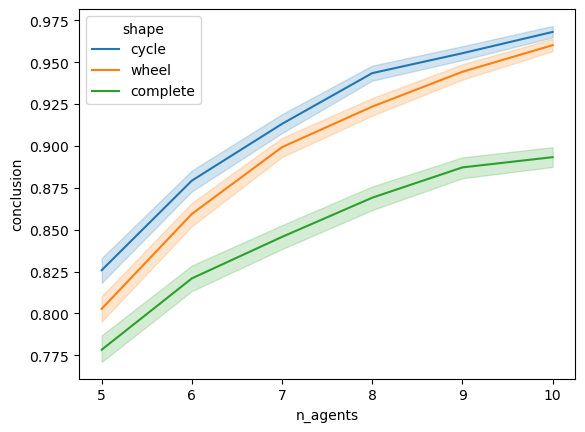

In [ ]:
sns.lineplot(df, x="n_agents", y="conclusion", hue="shape", errorbar="ci")

<Axes: xlabel='n_agents', ylabel='steps'>

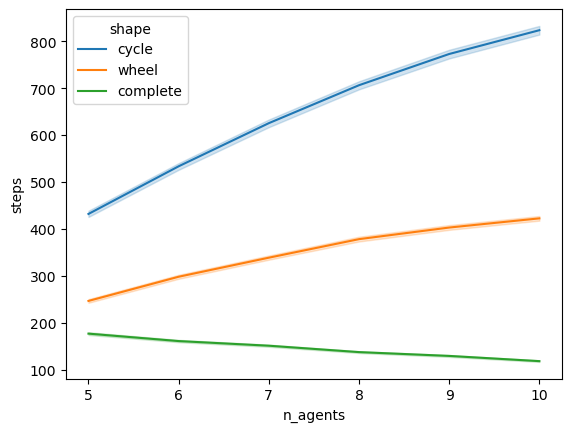

In [ ]:
sns.lineplot(df, x="n_agents", y="steps", hue="shape", errorbar="ci")

## Something goes wrong with the seeding! 

In [ ]:
net = simple_network(10, "wheel")
model1 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model1.run_simulation(number_of_steps=1_000)

model2 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model2.run_simulation(number_of_steps=1_000)

model3 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model3.run_simulation(number_of_steps=1_000)

print(f"{model1.conclusion=:.3f}")
print(f"{model2.conclusion=:.3f}")
print(f"{model3.conclusion=:.3f}")
print("-"*20)
print(f"{model1.n_steps=:.0f}")
print(f"{model2.n_steps=:.0f}")
print(f"{model3.n_steps=:.0f}")

In [ ]:
net = simple_network(10, "wheel")
model1 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model1.run_simulation(number_of_steps=1_000)

model2 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model2.run_simulation(number_of_steps=1_000)

model3 = VectorizedModel(network=net, n_experiments=1_000, uncertainty=0.001, agent_type="bayes")
model3.run_simulation(number_of_steps=1_000)

print(f"{model1.conclusion=:.3f}")
print(f"{model2.conclusion=:.3f}")
print(f"{model3.conclusion=:.3f}")
print("-"*20)
print(f"{model1.n_steps=:.0f}")
print(f"{model2.n_steps=:.0f}")
print(f"{model3.n_steps=:.0f}")